In [1]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

In [2]:
X_train = np.array([[2104, 5, 1, 45], 
                    [1416,3, 2, 40], 
                    [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [3]:
print(f"X shape = {X_train.shape}, X type = {type(X_train)}")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X shape = (3, 4), X type = <class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


In [4]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


In [5]:
def predict_single_loop(x, w, b):
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = w[i] * x[i]
        p = p + p_i
    p = p + b
    return p
        

In [6]:
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


In [7]:
def predict(x, w, b):
    p = np.dot(w, x) + b
    return p


In [8]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.99999761940825


In [9]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost += (f_wb_i - y[i]) ** 2
    cost = cost / (2 * m) 
    return cost

In [10]:
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904880036537e-12


In [24]:
def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    
    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i, j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

In [25]:
# compute and display gradient
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f"dj_db at initial w, b: {tmp_dj_db}")
print(f"dj_dw at initial w, b: {tmp_dj_dw}")


dj_db at initial w, b: -1.673925169143331e-06
dj_dw at initial w, b: [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


In [26]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X,y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            J_history.append( cost_function(X, y, w, b))

        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

    return w, b, J_history
    

In [35]:
initial_w = np.zeros_like(w_init)
initial_b = 0.
iterations = 20
alpha = 5.0e-7

w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)
print(f"w, b found by gradient descent: {w_final}, {b_final:0.2f}")

m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(w_final, X_train[i]) + b_final:0.2f}, target_value: {y_train[i]} ")

Iteration    0: Cost  2529.46   
Iteration    2: Cost   699.63   
Iteration    4: Cost   697.03   
Iteration    6: Cost   697.00   
Iteration    8: Cost   696.98   
Iteration   10: Cost   696.96   
Iteration   12: Cost   696.94   
Iteration   14: Cost   696.92   
Iteration   16: Cost   696.90   
Iteration   18: Cost   696.87   
w, b found by gradient descent: [ 2.02e-01  5.31e-04 -6.64e-05  3.67e-03], 0.00
prediction: 425.60, target_value: 460 
prediction: 286.47, target_value: 232 
prediction: 172.41, target_value: 178 


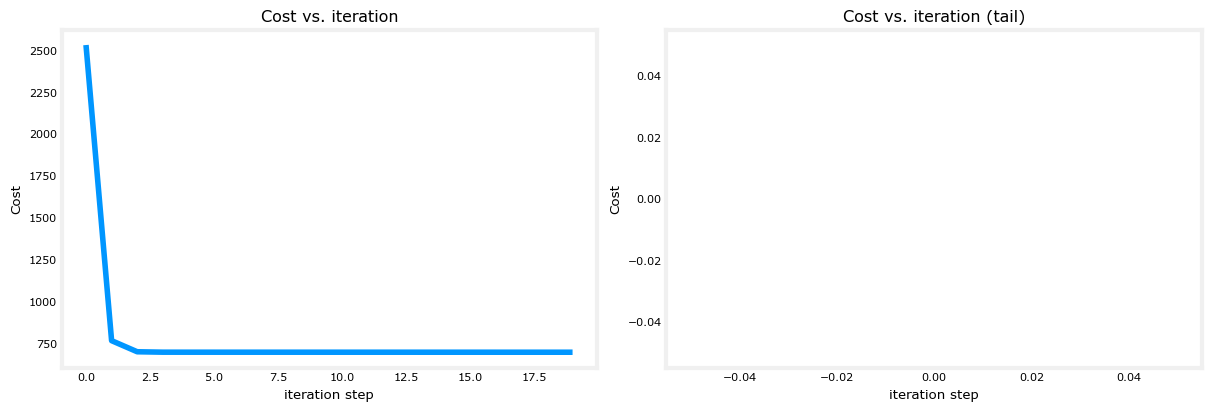

In [36]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()